# 69 - CIFAR-100: a serious CNN

**Section:** CNNs | **Prereqs:** `CNNs/EMNIST.ipynb` | **Next:** `CNNs/Examining_Feature_Maps.ipynb`

100 classes, 500 training images each, 32x32 colour. Small images, many classes,
little data per class - hard enough that every technique in the course is needed
at once. This is the most complete training recipe in the repository.

**The VGG-style architecture:** four blocks of `[Conv-BN-ReLU] x2 -> MaxPool ->
Dropout`, channels doubling each block (64 -> 128 -> 256 -> 512), then global
average pooling and a small classifier. Two 3x3 convolutions in a row see the same
5x5 receptive field as one 5x5 convolution, with fewer parameters and an extra
non-linearity - which is the whole idea behind VGG.

**Everything applied together**

| Technique | Setting |
|---|---|
| Augmentation | RandomCrop with padding, horizontal flip, AutoAugment |
| Normalisation | per-channel CIFAR-100 mean/std |
| BatchNorm | after every conv (with `bias=False` on the conv) |
| Dropout | 0.25 between blocks, 0.5 in the classifier |
| Weight decay | 5e-4 |
| Label smoothing | 0.1 |
| Optimizer | SGD, momentum 0.9, Nesterov |
| Schedule | cosine annealing over 150 epochs |

**Two of these are new.** *Label smoothing* replaces the one-hot target with
0.9/0.1 mass, so the model is never rewarded for infinite confidence - it
calibrates better and overfits less. *Cosine annealing* decays the learning rate
smoothly from 0.1 to 0, which has become the default schedule for vision models.

**A note on the SGD choice:** with a good schedule, SGD+momentum still beats Adam
on image classification. Adam is more forgiving; tuned SGD generalises better.

**The debugging trick worth stealing:** `print_toggle` prints the tensor shape
after every block. When a CNN will not run, this finds the offending layer in one
pass.

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

import torchvision
import torchvision.transforms as T

from sklearn.model_selection import train_test_split
from torchsummary import summary

In [135]:
# CIFAR-100: 50000 train, 10000 test, 32x32 RGB, 100 classes (500 images each).
raw_data_train = torchvision.datasets.CIFAR100(train = True,root='/',download=True)
raw_data_test = torchvision.datasets.CIFAR100(train =False,root='/',download=True)

In [136]:
raw_data_train, raw_data_test

(Dataset CIFAR100
     Number of datapoints: 50000
     Root location: /
     Split: Train,
 Dataset CIFAR100
     Number of datapoints: 10000
     Root location: /
     Split: Test)

In [137]:
# 90/10 train/validation split.
train_data = raw_data_train.data
train_label = raw_data_train.targets

train_data, val_data , train_label, val_label = train_test_split(train_data, train_label, test_size=0.10)

array([[[235, 233, 245],
        [218, 215, 235],
        [215, 212, 229],
        ...,
        [214, 214, 236],
        [220, 222, 238],
        [242, 241, 253]],

       [[213, 209, 232],
        [187, 181, 216],
        [179, 174, 209],
        ...,
        [179, 180, 215],
        [192, 192, 221],
        [224, 221, 241]],

       [[205, 201, 223],
        [174, 167, 205],
        [164, 157, 199],
        ...,
        [166, 170, 205],
        [182, 182, 209],
        [218, 215, 235]],

       ...,

       [[206, 186, 185],
        [175, 143, 142],
        [169, 127, 127],
        ...,
        [178, 140, 125],
        [194, 161, 149],
        [229, 204, 198]],

       [[211, 195, 195],
        [179, 156, 155],
        [172, 140, 139],
        ...,
        [191, 154, 145],
        [206, 171, 166],
        [231, 209, 207]],

       [[224, 215, 215],
        [203, 190, 188],
        [200, 183, 180],
        ...,
        [211, 187, 184],
        [220, 197, 196],
        [240, 226, 226]]], dtype=uint8)
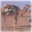

In [138]:
train_data[0]

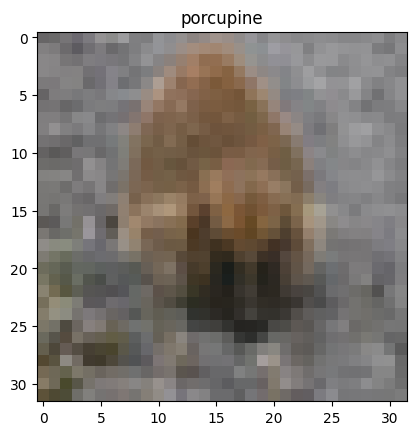

In [139]:
# A sample. At 32x32 many CIFAR-100 classes are hard for a human, which is worth
# remembering when reading the accuracy: ~75% is a strong result here.
plt.imshow(train_data[10])
plt.title(raw_data_train.classes[train_label[10]]);

In [140]:
# TensorDataset??

In [141]:
# The custom Dataset.
class CustomDataset(Dataset):

    def __init__(self, tensors, transform=None) -> None:
        if any(tensors[0].size(0) != tensor.size(0) for tensor in tensors):
            raise AssertionError("Size mismatch between tensors")
        self.tensors = tensors
        self.transform = transform


    def __getitem__(self, index):
        if self.transform:
          x = self.transform(self.tensors[0][index])
        else:
          x = self.tensors[0][index]

        y = self.tensors[1][index]
        return x,y

    def __len__(self) -> int:
        return self.tensors[0].size(0)

In [142]:
issubclass(CustomDataset, Dataset)

True

In [143]:
# The augmentation pipeline, and the strongest one in this course:
#   RandomCrop(32, padding=4)  - pad then crop, i.e. random translation,
#   RandomHorizontalFlip       - valid here (a mirrored cat is a cat),
#   AutoAugment(CIFAR10)       - a learned augmentation policy from the paper,
#   Normalize(mean, std)       - per-CHANNEL CIFAR-100 statistics.
# The validation pipeline has no randomness, only normalisation - as it must.
transformations = train_transform = T.Compose([
    T.ToPILImage(),
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.AutoAugment(T.AutoAugmentPolicy.CIFAR10),
    T.ToTensor(),
    T.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

val_transform = T.Compose([
    T.ToPILImage(),
    T.ToTensor(),
    T.Normalize(
    mean=(0.5071, 0.4867, 0.4408),
    std=(0.2675, 0.2565, 0.2761)
)
])

transformations, val_transform

(Compose(
     ToPILImage()
     RandomCrop(size=(32, 32), padding=4)
     RandomHorizontalFlip(p=0.5)
     AutoAugment(policy=AutoAugmentPolicy.CIFAR10, fill=None)
     ToTensor()
     Normalize(mean=(0.5071, 0.4867, 0.4408), std=(0.2675, 0.2565, 0.2761))
 ),
 Compose(
     ToPILImage()
     ToTensor()
     Normalize(mean=(0.5071, 0.4867, 0.4408), std=(0.2675, 0.2565, 0.2761))
 ))

In [144]:
# .permute(0,3,1,2) converts numpy's (N,H,W,C) to PyTorch's (N,C,H,W).
# permute REORDERS axes; view would reinterpret the memory and scramble the
# image. This is the single most common CIFAR bug.
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')

print(device)

train_data_tensor = torch.tensor(train_data, dtype=torch.float, device=device).permute(0,3,1,2)
train_label_tensor = torch.tensor(train_label, dtype=torch.long, device=device)

val_data_tensor = torch.tensor(val_data, dtype=torch.float, device=device).permute(0,3,1,2)
val_label_tensor = torch.tensor(val_label, dtype=torch.long, device=device)

train_dataset = CustomDataset((train_data_tensor, train_label_tensor), transform=transformations)
val_dataset = CustomDataset((val_data_tensor, val_label_tensor), transform=val_transform)

cuda


In [145]:
# Batch 512 - large, to keep the GPU busy on a model this deep.
# (shuffle=True and drop_last=True on the VALIDATION loader are unnecessary and
# drop_last can silently discard validation samples.)
bs = 512
train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=val_dataset.tensors[0].shape[0], shuffle=True, drop_last=True)

In [146]:
x = val_loader.dataset.tensors[1]
x.shape

torch.Size([5000])

In [147]:
a,b = next(iter(train_loader))
a.shape,b.shape

(torch.Size([512, 3, 32, 32]), torch.Size([512]))

In [156]:
# The VGG-style network. Per block: two 3x3 convs, each Conv-BN-ReLU, then pool
# and dropout. Channels double as resolution halves: 32 -> 16 -> 8 -> 4.
#
# bias=False on every conv, because the BatchNorm immediately after has its own
# shift parameter and makes the conv bias redundant.
#
# Two stacked 3x3 convs have the same 5x5 receptive field as one 5x5 conv, with
# fewer parameters and an extra non-linearity - the core VGG insight.
#
# print_toggle prints the shape after each block: the fastest way to debug a
# CNN that will not run.
class CNNmodel(nn.Module):
    def __init__(self, print_toggle=False):
        super().__init__()

        self.print_toggle = print_toggle

        # Block 1
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(64)

        # Block 2
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False)
        self.bn4 = nn.BatchNorm2d(128)

        # Block 3
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False)
        self.bn5 = nn.BatchNorm2d(256)

        self.conv6 = nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False)
        self.bn6 = nn.BatchNorm2d(256)

        # Block 4
        self.conv7 = nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False)
        self.bn7 = nn.BatchNorm2d(512)

        self.conv8 = nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False)
        self.bn8 = nn.BatchNorm2d(512)

        self.pool = nn.MaxPool2d(2, 2)
        self.drop_conv = nn.Dropout(0.25)

        self.gap = nn.AdaptiveAvgPool2d((1, 1))


        self.fc1 = nn.Linear(512, 256)
        self.drop_fc = nn.Dropout(0.5)
        self.out = nn.Linear(256, 100)

    def forward(self, x):
        if self.print_toggle:
            print(f'Input Shape: {x.shape}')

        # Block 1: 32x32 -> 16x16
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.drop_conv(x)
        if self.print_toggle:
            print(f'After Block 1: {x.shape}')

        # Block 2: 16x16 -> 8x8
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)
        x = self.drop_conv(x)
        if self.print_toggle:
            print(f'After Block 2: {x.shape}')

        # Block 3: 8x8 -> 4x4
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool(x)
        x = self.drop_conv(x)
        if self.print_toggle:
            print(f'After Block 3: {x.shape}')

        # Block 4: stay 4x4
        x = F.relu(self.bn7(self.conv7(x)))
        x = F.relu(self.bn8(self.conv8(x)))
        if self.print_toggle:
            print(f'After Block 4: {x.shape}')

        # Global average pooling
        x = self.gap(x)
        if self.print_toggle:
            print(f'After GAP: {x.shape}')

        x = x.view(x.size(0), -1)
        if self.print_toggle:
            print(f'After Flatten: {x.shape}')

        x = F.relu(self.fc1(x))
        x = self.drop_fc(x)

        return self.out(x)

In [157]:
# One forward pass with printing on, to verify the shapes end-to-end before
# committing to 150 epochs.
x,y = next(iter(train_loader))
model = CNNmodel(True)
out = model(x)

Input Shape: torch.Size([512, 3, 32, 32])
After Block 1: torch.Size([512, 64, 16, 16])
After Block 2: torch.Size([512, 128, 8, 8])
After Block 3: torch.Size([512, 256, 4, 4])
After Block 4: torch.Size([512, 512, 4, 4])
After GAP: torch.Size([512, 512, 1, 1])
After Flatten: torch.Size([512, 512])


In [158]:
out.shape

torch.Size([512, 100])

In [159]:
# The full layer-by-layer summary and parameter count.
model.to(device)
summary(model, (3,32,32))

Input Shape: torch.Size([2, 3, 32, 32])
After Block 1: torch.Size([2, 64, 16, 16])
After Block 2: torch.Size([2, 128, 8, 8])
After Block 3: torch.Size([2, 256, 4, 4])
After Block 4: torch.Size([2, 512, 4, 4])
After GAP: torch.Size([2, 512, 1, 1])
After Flatten: torch.Size([2, 512])
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
            Conv2d-3           [-1, 64, 32, 32]          36,864
       BatchNorm2d-4           [-1, 64, 32, 32]             128
         MaxPool2d-5           [-1, 64, 16, 16]               0
           Dropout-6           [-1, 64, 16, 16]               0
            Conv2d-7          [-1, 128, 16, 16]          73,728
       BatchNorm2d-8          [-1, 128, 16, 16]             256
            Conv2d-9          [-1, 128, 16, 16]         147,456
      BatchN

In [164]:
# The complete recipe:
#   label_smoothing=0.1 - targets become 0.9/0.1 instead of 1/0, so the model is
#     never pushed to infinite confidence; it calibrates better and overfits less,
#   SGD + momentum 0.9 + Nesterov + weight_decay 5e-4 - the standard vision
#     optimizer; better final accuracy than Adam when the schedule is right,
#   CosineAnnealingLR over 150 epochs - lr decays smoothly from 0.1 to ~0.
# scheduler.step() is called once per EPOCH (T_max is in the same units).
def train_model(printToggle = False):

  model = CNNmodel(printToggle).to(device)

  lossfunc = nn.CrossEntropyLoss(label_smoothing=0.1)
  epochs = 150
  optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4,
    nesterov=True
    )
  scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)


  losses = []
  train_acc = []
  val_acc = []

  for epoch in range(epochs):

    model.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:
      x = x.to(device) # ToPILimage takes it back to cpu
      y = y.to(device)
      yhat = model(x)

      loss = lossfunc(yhat,y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      acc = 100 * torch.mean( (torch.argmax(yhat, dim=1) == y).float().detach().cpu())
      batch_acc.append(acc)

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Now validation

    model.eval()
    with torch.no_grad():
      X,Y = next(iter(val_loader))
      X = X.to(device)
      Y = Y.to(device)
      val_acc.append( 100 * torch.mean( (torch.argmax(model(X), dim=1) == Y).float().detach().cpu()) )

    scheduler.step()

    if epoch % 10 == 0 or epoch == epochs-1 :
      print(f'Epoch {epoch} | Loss : {losses[epoch]:.4f} | Train Acc {train_acc[epoch]} | Val Acc : {val_acc[epoch]}')

  return model, losses, train_acc, val_acc

In [165]:
# The long run. Expect this to take a while even on a GPU.
model, loss, train_acc, val_acc = train_model()

Epoch 0 | Loss : 4.4347 | Train Acc 3.681752920150757 | Val Acc : 4.340000152587891
Epoch 10 | Loss : 3.0281 | Train Acc 33.08863067626953 | Val Acc : 43.040000915527344
Epoch 20 | Loss : 2.6618 | Train Acc 43.74102020263672 | Val Acc : 53.60000228881836
Epoch 30 | Loss : 2.4895 | Train Acc 48.97629165649414 | Val Acc : 58.53999710083008
Epoch 40 | Loss : 2.3633 | Train Acc 53.09132385253906 | Val Acc : 59.71999740600586
Epoch 50 | Loss : 2.2700 | Train Acc 55.74488067626953 | Val Acc : 60.619998931884766
Epoch 60 | Loss : 2.2073 | Train Acc 57.648616790771484 | Val Acc : 62.80000305175781
Epoch 70 | Loss : 2.1068 | Train Acc 60.79157638549805 | Val Acc : 65.06000518798828
Epoch 80 | Loss : 2.0498 | Train Acc 62.416934967041016 | Val Acc : 66.15999603271484
Epoch 90 | Loss : 1.9606 | Train Acc 65.39376831054688 | Val Acc : 68.63999938964844
Epoch 100 | Loss : 1.8791 | Train Acc 67.83853912353516 | Val Acc : 69.18000030517578
Epoch 110 | Loss : 1.7974 | Train Acc 70.93885040283203 | Val

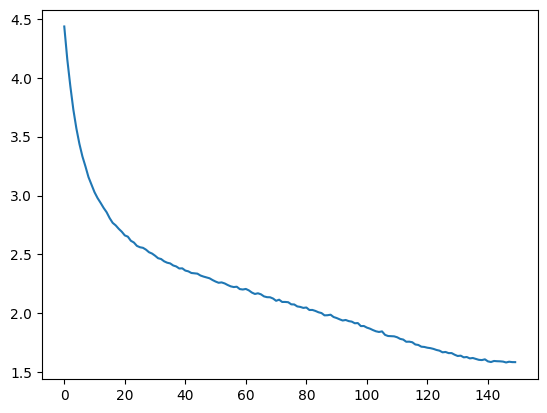

In [166]:
# Loss curve. With cosine annealing it should keep improving to the end rather
# than plateauing - the late small steps are where the last points come from.
plt.plot(loss);

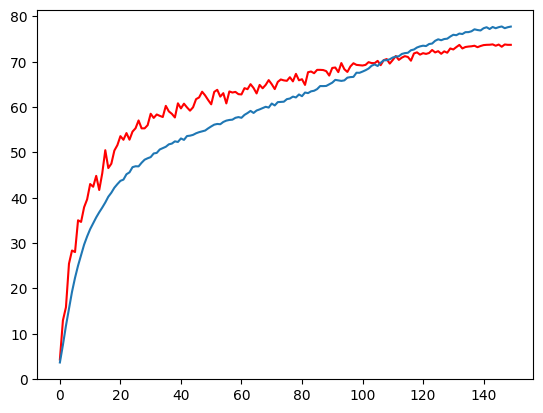

In [167]:
# Train vs validation accuracy. Train may sit below validation early on, because
# training is measured with dropout and heavy augmentation active.
val_acc = [i.cpu() for i in val_acc]

plt.plot(val_acc, 'r-')
plt.plot(train_acc);

## TESTING

In [168]:
# The untouched test set with the validation transform.
test_data_tensor = torch.tensor(raw_data_test.data, dtype=torch.float, device=device).permute(0,3,1,2)
test_label_tensor = torch.tensor(raw_data_test.targets, dtype=torch.long, device=device)


test_dataset = CustomDataset((test_data_tensor, test_label_tensor), transform=val_transform)

In [169]:
test_dataset.tensors[0].shape[0]

10000

In [170]:
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0], shuffle=False)
print(f'Corrected Test Loader Samples: {len(test_loader.dataset)}')

Corrected Test Loader Samples: 10000


In [171]:
# Final test evaluation.
with torch.no_grad():
  model.eval()
  a, b = next(iter(test_loader))
  test_predictions = model(a.to(device))

  test_acc = 100 * torch.mean( (torch.argmax(test_predictions, dim=1) == b.to(device)).float().detach().cpu())


In [172]:
# Test accuracy on 100 classes. Chance is 1%; anything above 70% is a good
# result for a from-scratch model at this size.
test_acc

tensor(73.8100)

In [173]:
# The per-class report - 100 rows. Scan for classes with near-zero recall; they
# are usually the ones with a close visual neighbour in the label set.
from sklearn.metrics import classification_report

preds = torch.argmax(test_predictions, dim=1).cpu().numpy()
true_labels = b.cpu().numpy()

print(classification_report(true_labels, preds, target_names=raw_data_test.classes))

               precision    recall  f1-score   support

        apple       0.86      0.89      0.87       100
aquarium_fish       0.90      0.86      0.88       100
         baby       0.66      0.65      0.66       100
         bear       0.69      0.58      0.63       100
       beaver       0.52      0.67      0.59       100
          bed       0.75      0.81      0.78       100
          bee       0.72      0.80      0.76       100
       beetle       0.71      0.70      0.70       100
      bicycle       0.88      0.88      0.88       100
       bottle       0.91      0.79      0.84       100
         bowl       0.71      0.58      0.64       100
          boy       0.51      0.52      0.51       100
       bridge       0.83      0.84      0.84       100
          bus       0.69      0.65      0.67       100
    butterfly       0.80      0.71      0.75       100
        camel       0.63      0.80      0.70       100
          can       0.76      0.78      0.77       100
       ca

In [174]:
# Save the weights (state_dict, not the model object) - see
# More on Data/Importing_data&Saving_models.ipynb. After a 150-epoch run you do
# not want to retrain to get the model back.
torch.save(model.state_dict(), "model.pth")